In [28]:
import functions as fn
import pandas as pd
import pickle as pkl
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import re



# An Example of Chapter 3 Workflow

In [6]:
# We begin by generating a collection of random graphs

# We will generate 20 random graphs with 100 nodes, with edge probabilites in {0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9}
n_graphs = 10
N = 100
p_list = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


# Generate graphs and store in DataFrame
data = []
for p in p_list:
    for _ in range(n_graphs):
        matrix = fn.gen_graph_mat(N, p)
        data.append({
            'graph_matrix': matrix,
            'N': N,
            'p': p
        })

df_graphs = pd.DataFrame(data)
df_graphs




,graph_matrix,N,p
0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",100,0.05
1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0,...",100,0.05
2,"[[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",100,0.05
3,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",100,0.05
4,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0,...",100,0.05
...,...,...,...
95,"[[0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0,...",100,0.90
96,"[[0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0,...",100,0.90
97,"[[0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0,...",100,0.90
98,"[[0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0,...",100,0.90


## Example of Solution Workflow

In [10]:
# We will find the MSS of each graph using some of the formulations from our project and record the time taken for the
#  solver to find the size of the set and the size of the set itself. 

formulations_list = ["E1B1", "E1B2", "E1B4"]




for idx, row in df_graphs.iterrows():
    matrix = row["graph_matrix"]
    
    for model in formulations_list:
        try:
            sol_time, opt_val = fn.solve_problem(model, matrix)
            df_graphs.at[idx, f"{model}_solution_times"] = sol_time
            df_graphs.at[idx, f"{model}_optimal_values"] = opt_val

        except Exception as e:
            # Handle any solver errors gracefully
            print(f"Error for row {idx}, model {model}: {e}")
            df_graphs.at[idx, f"{model}_solution_times"] = None
            df_graphs.at[idx, f"{model}_optimal_values"] = None


## The data can be save to a pickle file with the following line, be careful not to overwrite any existing files with the same name. 
 ## Saving to an Excel file can allow easy inspection of results, identifying possible errors

##df_graphs.to_pickle("E1B1_N200_Markov_Solutions_noB3.pkl")
##df_graphs.to_excel("E1B1_N200_Markov_Solutions_noB3.xlsx")

Set parameter Username
Academic license - for non-commercial use only - expires 2026-11-22
Set parameter NonConvex to value 2
Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (mac64[arm] - Darwin 24.2.0 24C101)

CPU model: Apple M4 Pro
Thread count: 12 physical cores, 12 logical processors, using up to 12 threads

Non-default parameters:
NonConvex  2

Optimize a model with 0 rows, 100 columns and 0 nonzeros (Max)
Model fingerprint: 0xc37b561e
Model has 100 linear objective coefficients
Model has 242 quadratic constraints
Variable types: 0 continuous, 100 integer (100 binary)
Coefficient statistics:
  Matrix range     [0e+00, 0e+00]
  QMatrix range    [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [0e+00, 0e+00]
Found heuristic solution: objective -0.0000000
Presolve added 185 rows and 0 columns
Presolve removed 0 rows and 13 columns
Presolve time: 0.00s
Presolved: 185 rows, 87 columns, 379 nonzeros
Found heuristic solution: objecti

## Generating Box Plots

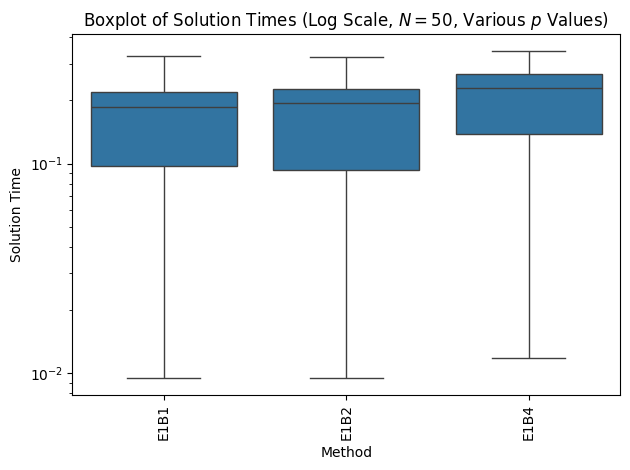

In [19]:
solution_time_cols = [col for col in df_graphs.columns if "solution_times" in col]

data_long = df_graphs[solution_time_cols].melt(
    var_name="Method",
    value_name="Solution Time"
)


data_long["Method"] = (
    data_long["Method"]
    .str.replace(r"_?solution_times_?", "", regex=True)
)

plt.figure()
sns.boxplot(x="Method", y="Solution Time", data=data_long)

plt.yscale("log")
plt.xticks(rotation=90)
plt.title(r"Boxplot of Solution Times (Log Scale, $N = 50$, Various $p$ Values)")
plt.tight_layout()
plt.show()

# Plot Performance Profiles

Found 3 solvers.
Using 100 valid problems.


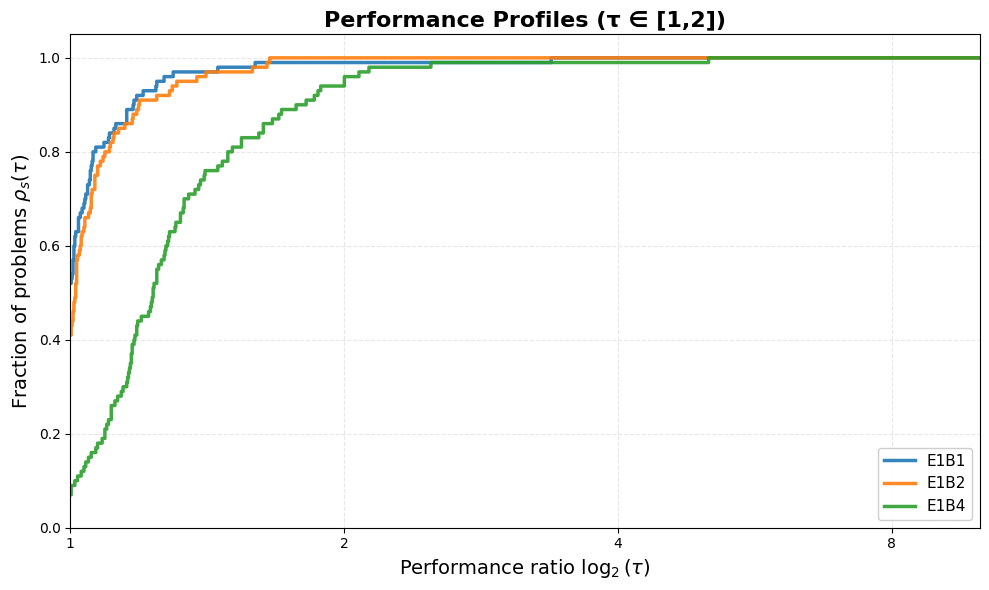


PERFORMANCE PROFILE STATISTICS

E1B1:
  - Best on 52/100 (52.0%)
  - Worst on 15/100 (15.0%)
  - Efficiency (τ ≤ 1.1): 82.0%
  - Efficiency (τ ≤ 1.5): 98.0%
  - Efficiency (τ ≤ 2.0): 99.0%
  - Worst ratio observed: 3.38

E1B2:
  - Best on 41/100 (41.0%)
  - Worst on 9/100 (9.0%)
  - Efficiency (τ ≤ 1.1): 80.0%
  - Efficiency (τ ≤ 1.5): 97.0%
  - Efficiency (τ ≤ 2.0): 100.0%
  - Worst ratio observed: 1.66

E1B4:
  - Best on 7/100 (7.0%)
  - Worst on 76/100 (76.0%)
  - Efficiency (τ ≤ 1.1): 23.0%
  - Efficiency (τ ≤ 1.5): 80.0%
  - Efficiency (τ ≤ 2.0): 95.0%
  - Worst ratio observed: 5.02


In [30]:
solution_time_cols = [col for col in df_graphs.columns if col.endswith("_solution_times")]

# Find the fastest solution time across all methods for each graph
df_graphs["min_solution_time"] = df_graphs[solution_time_cols].min(axis=1)

# Column (method) that produced the minimum
df_graphs["best_method"] = (
    df_graphs[solution_time_cols]
    .idxmin(axis=1)
    .str.replace("_solution_times", "", regex=False)
)

new_df = df_graphs
# Select solution time columns
solution_time_cols = [col for col in df_graphs.columns if col.endswith("_solution_times")]

# Total sum across all solution time columns and all rows
total_solution_time = new_df[solution_time_cols].sum().sum()

# total_solution_time

# Create Performance Ratio columns
for col in solution_time_cols:
    ratio_col = col.replace("_solution_times", "_solution_time_ratio")
    df_graphs[ratio_col] = df_graphs[col] / df_graphs["min_solution_time"]


num_cols = df_graphs.select_dtypes(include=[np.number]).columns
df_graphs[num_cols] = df_graphs[num_cols].replace([np.inf, -np.inf], np.nan)



# Detect ratio columns
rel_cols = [
    col for col in df_graphs.columns
    if col.endswith("_solution_time_ratio")
]

if not rel_cols:
    raise ValueError("No *_solution_time_ratio columns found.")

# Sort by (E number, B number)
def solver_sort_key(col):
    match = re.search(r"E(\d+)B(\d+)", col)
    if match:
        return (int(match.group(1)), int(match.group(2)))
    return (999, 999)  # fallback if unexpected format

rel_cols = sorted(rel_cols, key=solver_sort_key)

if not rel_cols:
    raise ValueError("No *_solution_time_ratio columns found.")

print(f"Found {len(rel_cols)} solvers.")

# Convert to numeric and extract matrix
ratios = df_graphs[rel_cols].apply(pd.to_numeric, errors="coerce").values

# Remove rows with NaN or non-positive ratios
valid_mask = (
    ~np.any(np.isnan(ratios), axis=1) &
    ~np.any(ratios <= 0, axis=1)
)

ratios = ratios[valid_mask]
n_problems = ratios.shape[0]

print(f"Using {n_problems} valid problems.")


# Performance profile function (Dolan–Moré) Performance Ratios

def performance_profile(ratios, tau_max=10.0, n_pts=1000):
    tau = np.logspace(0, np.log10(tau_max), n_pts)
    tau = np.insert(tau, 0, 1.0)  # ensure τ=1 included
    rho = np.mean(ratios[:, :, np.newaxis] <= tau, axis=0)
    return tau, rho

tau_log, rho_log = performance_profile(ratios, tau_max=10)

# Solver labels
solver_labels = [
    col.replace("_solution_time_ratio", "")
    for col in rel_cols
]

# Color palette (enough for up to 10 solvers)
colors = [
    '#1f77b4', '#ff7f0e', '#2ca02c',
    '#d62728', '#9467bd', '#8c564b',
    '#e377c2', '#7f7f7f', '#bcbd22',
    '#17becf'
]


## Log₂ performance profile (τ ∈ [1,2])

plt.figure(figsize=(10, 6))

for i in range(len(rel_cols)):
    plt.step(
        np.log2(tau_log),
        rho_log[i, :],
        where="post",
        label=solver_labels[i],
        linewidth=2.5,
        color=colors[i % len(colors)],
        alpha=0.9
    )

plt.xlabel(r"Performance ratio $\log_2(\tau)$", fontsize=14)
plt.ylabel(r"Fraction of problems $\rho_s(\tau)$", fontsize=14)
plt.title("Performance Profiles (τ ∈ [1,2])",
          fontsize=16, fontweight="bold")

plt.grid(True, which="both", ls="--", alpha=0.3)
plt.xlim(0, np.log2(10))
plt.ylim(0, 1.05)

plt.xticks(
    [0, 1, 2, 3],
    ['1', '2', '4', '8']
)
plt.legend(fontsize=11, loc="lower right", framealpha=0.95)

plt.tight_layout()
plt.savefig("perf_profile_log2_zoomed.pdf",
            dpi=300, bbox_inches="tight")
plt.show()



## Summary statistics

print("\n" + "="*50)
print("PERFORMANCE PROFILE STATISTICS")
print("="*50)

worst_ratios_per_problem = np.max(ratios, axis=1)
is_worst = ratios == worst_ratios_per_problem[:, np.newaxis]
worst_counts = np.sum(is_worst, axis=0)

for i in range(len(rel_cols)):
    ratios_solver = ratios[:, i]

    best_count = np.sum(ratios_solver == 1)
    worst_count = worst_counts[i]

    eff_1_1 = np.mean(ratios_solver <= 1.1)
    eff_1_5 = np.mean(ratios_solver <= 1.5)
    eff_2 = np.mean(ratios_solver <= 2)

    print(f"\n{solver_labels[i]}:")
    print(f"  - Best on {best_count}/{n_problems} "
          f"({100*best_count/n_problems:.1f}%)")
    print(f"  - Worst on {worst_count}/{n_problems} "
          f"({100*worst_count/n_problems:.1f}%)")
    print(f"  - Efficiency (τ ≤ 1.1): {100*eff_1_1:.1f}%")
    print(f"  - Efficiency (τ ≤ 1.5): {100*eff_1_5:.1f}%")
    print(f"  - Efficiency (τ ≤ 2.0): {100*eff_2:.1f}%")
    print(f"  - Worst ratio observed: {np.max(ratios_solver):.2f}")
